Loading data...
Training Logistic Regression model...

ROC-AUC Score: 0.6405

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18082
           1       0.51      0.01      0.03      2271

    accuracy                           0.89     20353
   macro avg       0.70      0.51      0.48     20353
weighted avg       0.85      0.89      0.84     20353



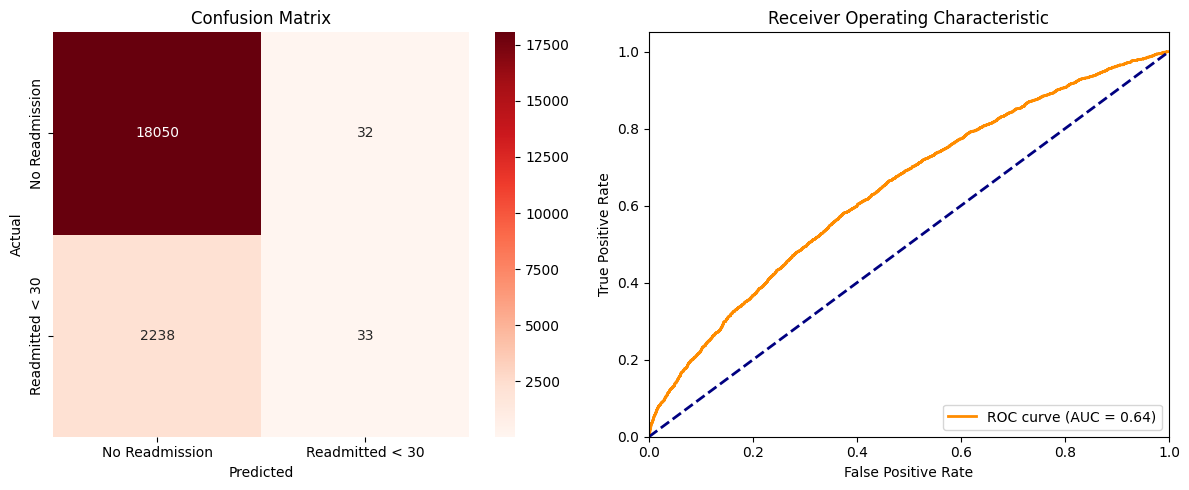

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report

# 1. Load Data
print("Loading data...")
df = pd.read_csv('/content/diabetic_data.csv')

# 2. Target Variable Setup
# Dataset mein 'readmitted' column mein 3 values hoti hain: '<30', '>30', 'NO'
# Humein sirf 30-day readmission risk predict karna hai
df['target'] = (df['readmitted'] == '<30').astype(int)

# 3. Feature Selection & Cleaning
# Basic clinical features select kar rahe hain for simplicity
features = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'age', 'gender'
]

df_subset = df[features + ['target']].copy()

# Gender mein kuch invalid entries hoti hain, unhe drop karte hain
df_subset = df_subset[df_subset['gender'] != 'Unknown/Invalid']

# Age (e.g., '[70-80)') aur Gender categorical hain, inhe One-Hot Encode karenge
df_encoded = pd.get_dummies(df_subset, columns=['age', 'gender'], drop_first=True)

# 4. Train-Test Split
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. Feature Scaling
# L2 Regularization ke liye features ka scale same hona zaruri hai
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Train Logistic Regression with L2 Regularization
print("Training Logistic Regression model...")
# C=1.0 is default inverse of regularization strength (L2 is default in sklearn)
model = LogisticRegression(penalty='l2', C=1.0, max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# 7. Predictions & Evaluation
y_pred_probs = model.predict_proba(X_test_scaled)[:, 1]
y_pred = model.predict(X_test_scaled)

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred_probs)
print(f"\nROC-AUC Score: {roc_auc:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

# 8. Visualizations
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', ax=ax[0],
            xticklabels=['No Readmission', 'Readmitted < 30'],
            yticklabels=['No Readmission', 'Readmitted < 30'])
ax[0].set_title('Confusion Matrix')
ax[0].set_ylabel('Actual')
ax[0].set_xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('Receiver Operating Characteristic')
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()